--- DATASET LOADED SUCCESSFULLY FROM UCI ARCHIVE ---
Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Training Set: (237, 13)
Testing Set: (60, 13)

--- MODEL TRAINED ---

Accuracy: 0.83
Precision: 0.85
Recall: 0.79


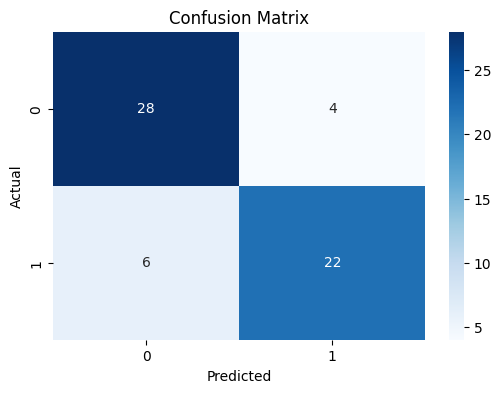


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# 1. Load Dataset from the OFFICIAL UCI ARCHIVE (Permanent Link)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# The official data has no headers, so we define them manually
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
         'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# We must handle '?' which represents missing values in this original file
df = pd.read_csv(url, names=names, na_values='?')

# Drop the few rows with missing values (clean it instantly)
df.dropna(inplace=True)

# Convert Target to Binary (0 = Healthy, 1+ = Disease) because the original has levels 0-4
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("--- DATASET LOADED SUCCESSFULLY FROM UCI ARCHIVE ---")
print(f"Shape: {df.shape}")
display(df.head())

# 2. Train-Test Split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

# 3. Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("\n--- MODEL TRAINED ---")

# 4. Predictions & Evaluation
y_pred = model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. Final Report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))